# Дообучение (fine-tuning) существующей модели

## Установка дополнительных пакетов

In [29]:
pip install soundfile

  Using cached soundfile-0.13.1-py2.py3-none-win_amd64.whl.metadata (16 kB)
Using cached soundfile-0.13.1-py2.py3-none-win_amd64.whl (1.0 MB)
Note: you may need to restart the kernel to use updated packages.


In [30]:
pip install soundfile librosa

  Using cached librosa-0.11.0-py3-none-any.whl.metadata (8.7 kB)
  Using cached audioread-3.1.0-py3-none-any.whl.metadata (9.0 kB)
  Using cached pooch-1.9.0-py3-none-any.whl.metadata (10 kB)
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.7 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.7 MB ? eta -:--:--
   ----------- ---------------------------- 0.8/2.7 MB 1.2 MB/s eta 0:00:02
   ----------- ---------------------------

In [48]:
!pip install torch==2.2.0 torchvision==0.17.0 torchaudio==2.2.0

   ---------------------------------------- 0.0/198.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/198.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/198.5 MB 487.6 kB/s eta 0:06:48
   ---------------------------------------- 0.1/198.5 MB 544.7 kB/s eta 0:06:05
   ---------------------------------------- 0.1/198.5 MB 573.4 kB/s eta 0:05:47
   ---------------------------------------- 0.1/198.5 MB 504.4 kB/s eta 0:06:34
   ---------------------------------------- 0.1/198.5 MB 532.5 kB/s eta 0:06:13
   ---------------------------------------- 0.2/198.5 MB 620.6 kB/s eta 0:05:20
   ---------------------------------------- 0.2/198.5 MB 655.6 kB/s eta 0:05:03
   ---------------------------------------- 0.3/198.5 MB 655.4 kB/s eta 0:05:03
   ---------------------------------------- 0.3/198.5 MB 678.0 kB/s eta 0:04:53
   ---------------------------------------- 0.4/198.5 MB 717.9 kB/s eta 0:04:37
   ---------------------------------------- 0.4/198.5 MB 7

In [51]:
!pip install transformers==4.38.0

     ---------------------------------------- 0.0/131.1 kB ? eta -:--:--
     --- ------------------------------------ 10.2/131.1 kB ? eta -:--:--
     ----- ------------------------------- 20.5/131.1 kB 217.9 kB/s eta 0:00:01
     ----- ------------------------------- 20.5/131.1 kB 217.9 kB/s eta 0:00:01
     -------- ---------------------------- 30.7/131.1 kB 163.8 kB/s eta 0:00:01
     -------------- ---------------------- 51.2/131.1 kB 201.8 kB/s eta 0:00:01
     ----------------- ------------------- 61.4/131.1 kB 204.8 kB/s eta 0:00:01
     -------------------- ---------------- 71.7/131.1 kB 206.9 kB/s eta 0:00:01
     -------------------------- ---------- 92.2/131.1 kB 249.8 kB/s eta 0:00:01
     --------------------------------- -- 122.9/131.1 kB 300.4 kB/s eta 0:00:01
     ------------------------------------ 131.1/131.1 kB 297.6 kB/s eta 0:00:00
  Using cached huggingface_hub-0.36.2-py3-none-any.whl.metadata (15 kB)
  Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl.meta

In [3]:
pip install datasets==2.20.0

INFO: pip is looking at multiple versions of multiprocess to determine which version is compatible with other requirements. This could take a while.
   ---------------------------------------- 0.0/547.8 kB ? eta -:--:--
   ---------------------------------------- 547.8/547.8 kB 3.0 MB/s  0:00:00

  Attempting uninstall: fsspec

    Found existing installation: fsspec 2026.2.0

    Uninstalling fsspec-2026.2.0:

      Successfully uninstalled fsspec-2026.2.0

   -------- ------------------------------- 1/5 [fsspec]
   -------- ------------------------------- 1/5 [fsspec]
   -------- ------------------------------- 1/5 [fsspec]
  Attempting uninstall: dill
   -------- ------------------------------- 1/5 [fsspec]
    Found existing installation: dill 0.4.0
   -------- ------------------------------- 1/5 [fsspec]
    Uninstalling dill-0.4.0:
   -------- ------------------------------- 1/5 [fsspec]
      Successfully uninstalled dill-0.4.0
   -------- ------------------------------- 1/5 [fs

In [49]:
pip install accelerate>=0.26.0

Note: you may need to restart the kernel to use updated packages.


## Подключение библиотек

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn 

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import utils
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [7]:
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import mean_squared_error, r2_score

In [9]:
import torch

In [10]:
from transformers import pipeline

In [11]:
import accelerate

In [12]:
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

In [13]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback
from datasets import Dataset, DatasetDict

## Загрузка данных

In [8]:
df = pd.read_csv("dataset/opensentimentcorpus-final-by-total-agreement-with-expert-validation.csv")

In [9]:
df.head(10)

,Sentence,Sentiment
0,"Не будущее, а то, что прожили.",neutral
1,На самом деле всё меньше удовлетворения принос...,negative
2,"Во-вторых, надо закрывать территориальные изби...",neutral
3,"На этих полотнах портреты семьи, людей из ближ...",neutral
4,Российский филолог Марина Орлова живёт в США и...,neutral
5,"Короче говоря, полный крах американских ценнос...",negative
6,Учёные обратились к коллегам в стране и мире.,neutral
7,“Человек должен будет открыть один раз расчетн...,neutral
8,"Масла в огонь подливают ведущие, в особенности...",negative
9,"Его объём составит 92,4 трлн иен (1,1 трлн дол...",neutral


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4487 entries, 0 to 4486
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Sentence   4487 non-null   object
 1   Sentiment  4487 non-null   object
dtypes: object(2)
memory usage: 70.2+ KB


In [11]:
for col in df.columns:
    print('Пропусков в колонке %s = %d' % (col, df[col].isna().sum()))

Пропусков в колонке Sentence = 0
Пропусков в колонке Sentiment = 0


In [12]:
df.duplicated().sum()

0

In [13]:
df['Sentiment'].value_counts()

Sentiment
neutral     2459
negative    1495
positive     533
Name: count, dtype: int64

In [14]:
# заменяем категориальные значения на численные
df['Sentiment'] = df['Sentiment'].map({'neutral':0, 
                                       'positive':1, 
                                       'negative':2})

### Описательная статистика

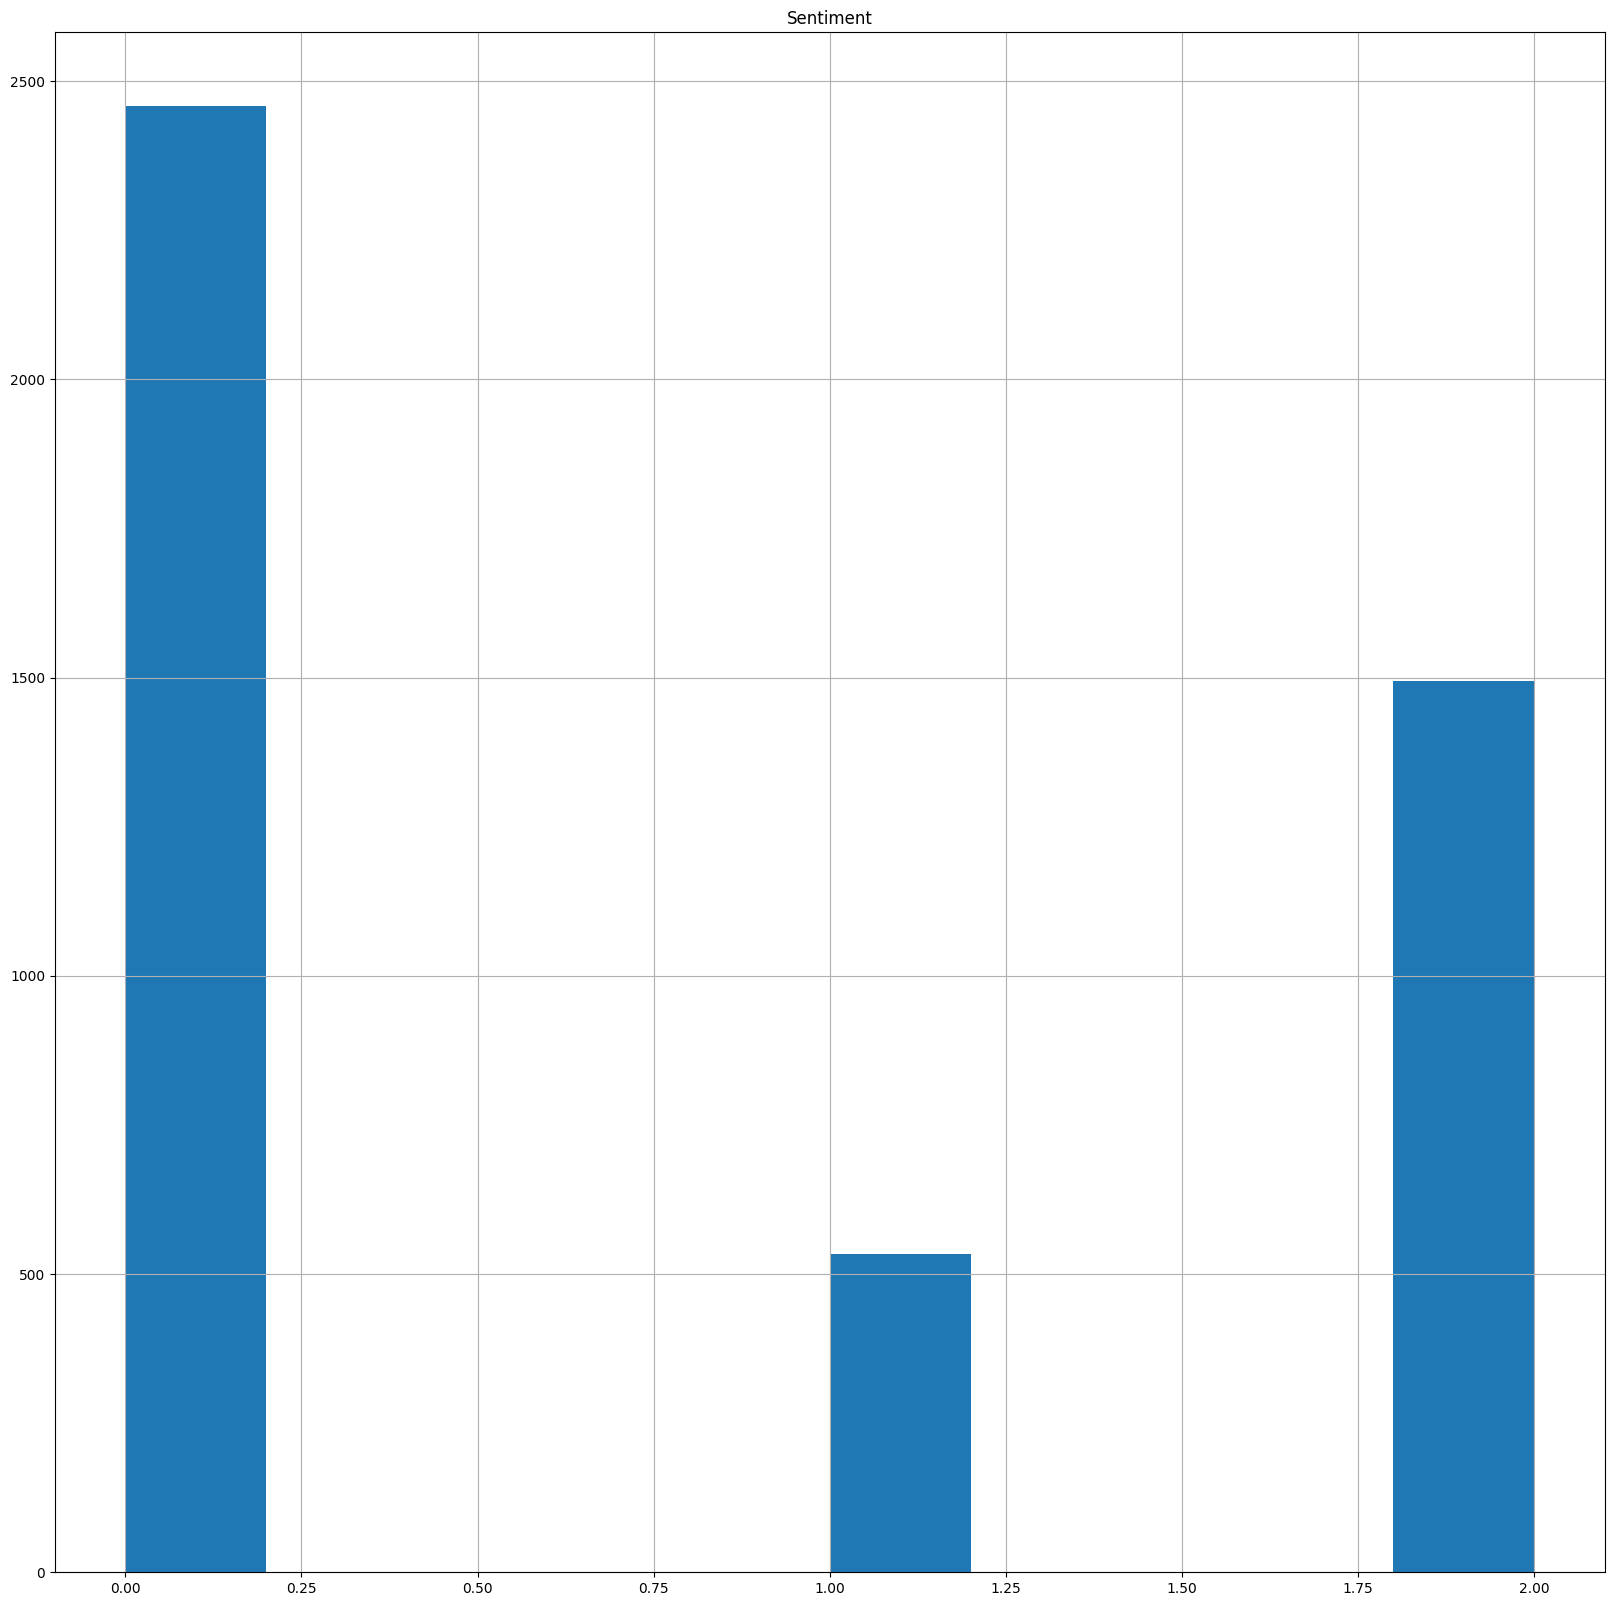

In [15]:
# гистаграммы всех признаков
df.hist(figsize=(20,20));

## Облако слов

In [16]:
pip install WordCloud

Note: you may need to restart the kernel to use updated packages.


In [17]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
%matplotlib inline

In [18]:
# Получение текстовой строки из списка слов
def str_corpus(corpus):
    str_corpus = ''
    try:
        for i in corpus:
            str_corpus += ' ' + i
        str_corpus = str_corpus.strip()
    except:
        pass
    return str_corpus

# Получение списка всех слов в корпусе
def get_corpus(data):
    corpus = []
    try:
        for phrase in data:
            for word in phrase.split():
                corpus.append(word)
    except:
        pass
    return corpus

def get_wordCloud(corpus):
    wordCloud = WordCloud(background_color='white',
                              stopwords=STOPWORDS,
                              width=3000,
                              height=2500,
                              max_words=200,
                              random_state=42
                         ).generate(str_corpus(corpus))
    return wordCloud

In [19]:
df.head()

,Sentence,Sentiment
0,"Не будущее, а то, что прожили.",0
1,На самом деле всё меньше удовлетворения принос...,2
2,"Во-вторых, надо закрывать территориальные изби...",0
3,"На этих полотнах портреты семьи, людей из ближ...",0
4,Российский филолог Марина Орлова живёт в США и...,0


In [20]:
neurtal_comment = df[df['Sentiment'] == 0]['Sentence']
positive_comment = df[df['Sentiment'] == 1]['Sentence']
negative_comment = df[df['Sentiment'] == 2]['Sentence']

In [21]:
len(neurtal_comment)

2459

In [22]:
len(positive_comment)

533

In [23]:
len(negative_comment)

1495

### Нейтральные комментарии

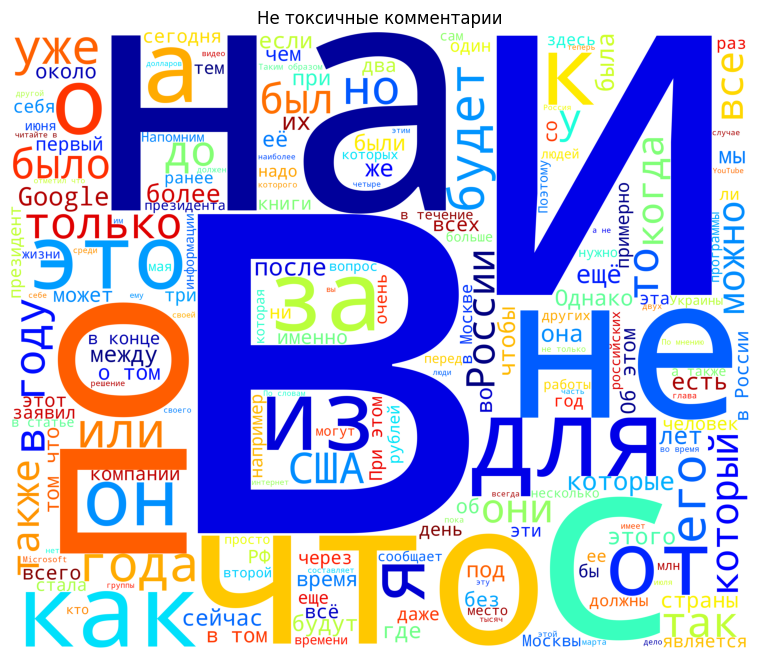

CPU times: total: 17.1 s
Wall time: 17.2 s


In [24]:
%%time
procWordCloud = WordCloud(background_color='white',
                              width=3000,
                              height=2500,
                              max_words=200,
                              random_state=42,
                              colormap='jet'
                         ).generate(' '.join(neurtal_comment))

plt.figure(figsize=(20, 8))
plt.imshow(procWordCloud)
plt.axis('off')
plt.title('Не токсичные комментарии')
plt.show()

### Не токсичные комментарии

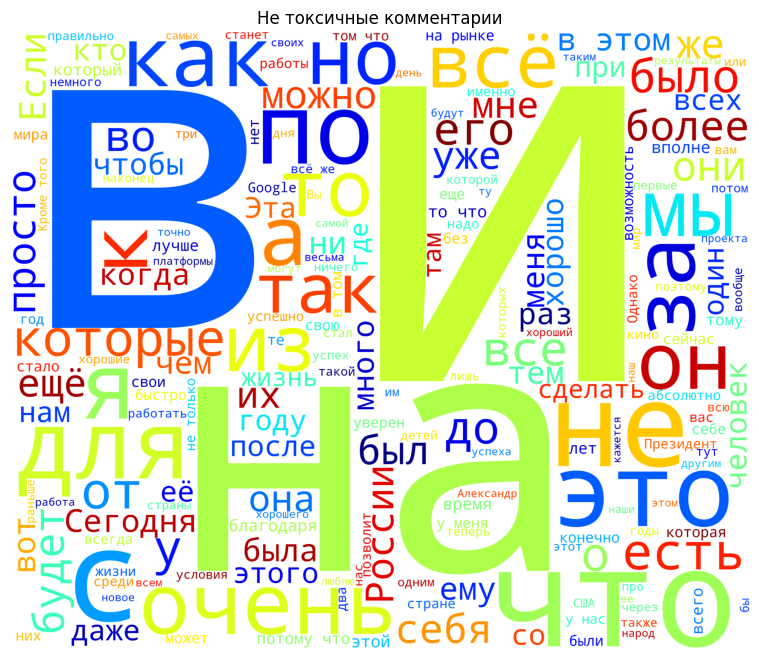

CPU times: total: 14.9 s
Wall time: 15.1 s


In [25]:
%%time
procWordCloud = WordCloud(background_color='white',
                              width=3000,
                              height=2500,
                              max_words=200,
                              random_state=42,
                              colormap='jet'
                         ).generate(' '.join(positive_comment))

plt.figure(figsize=(20, 8))
plt.imshow(procWordCloud)
plt.axis('off')
plt.title('Не токсичные комментарии')
plt.show()

### Токсичные комментарии

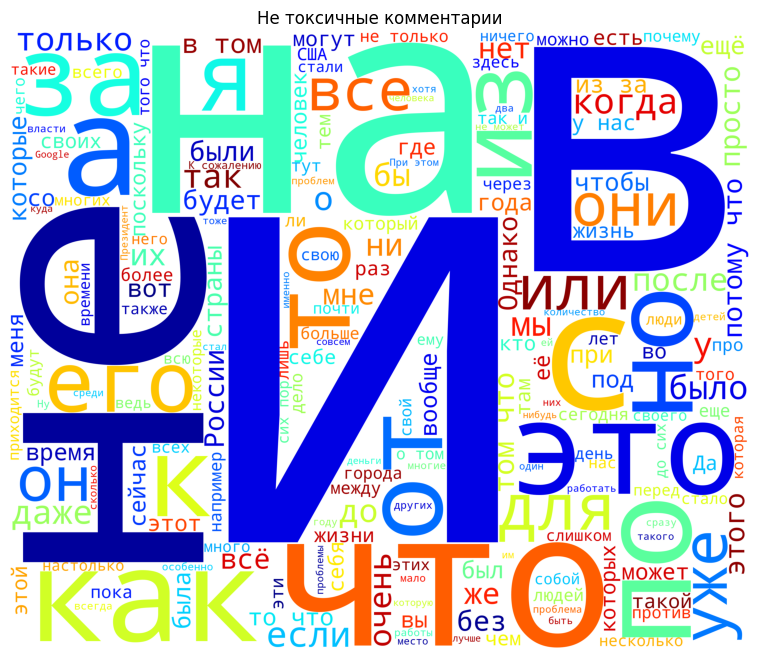

CPU times: total: 16.4 s
Wall time: 16.4 s


In [26]:
%%time
procWordCloud = WordCloud(background_color='white',
                              width=3000,
                              height=2500,
                              max_words=200,
                              random_state=42,
                              colormap='jet'
                         ).generate(' '.join(negative_comment))

plt.figure(figsize=(20, 8))
plt.imshow(procWordCloud)
plt.axis('off')
plt.title('Не токсичные комментарии')
plt.show()

## Дообучение модели - seara_rubert-tiny2-russian-sentiment

### Преобработка данных

In [29]:
df.head()

,Sentence,Sentiment
0,"Не будущее, а то, что прожили.",0
1,На самом деле всё меньше удовлетворения принос...,2
2,"Во-вторых, надо закрывать территориальные изби...",0
3,"На этих полотнах портреты семьи, людей из ближ...",0
4,Российский филолог Марина Орлова живёт в США и...,0


In [30]:
df.rename(columns={'Sentence': 'text', 'Sentiment': 'label'}, inplace=True)

In [31]:
# определяем выборку
x_train_mn, y_test_mn = train_test_split(df, test_size=0.18, random_state=19, stratify=df['label'])

In [32]:
x_train_mn.shape, y_test_mn.shape

((3679, 2), (808, 2))

Преобразуем датасет в необходимый для обучения модели

In [33]:
train_df_mn = Dataset.from_pandas(x_train_mn[['text', 'label']])
test_df_mn = Dataset.from_pandas(y_test_mn[['text', 'label']])

In [34]:
train_df_mn

Dataset({
    features: ['text', 'label', '__index_level_0__'],
    num_rows: 3679
})

In [35]:
test_df_mn

Dataset({
    features: ['text', 'label', '__index_level_0__'],
    num_rows: 808
})

In [36]:
data_all_df_mn = DatasetDict({'train': train_df_mn, 'test': test_df_mn})

In [37]:
data_all_df_mn

DatasetDict({
    train: Dataset({
        features: ['text', 'label', '__index_level_0__'],
        num_rows: 3679
    })
    test: Dataset({
        features: ['text', 'label', '__index_level_0__'],
        num_rows: 808
    })
})

### Загрузка и дообучение модели

In [46]:
model_name = "seara/rubert-tiny2-russian-sentiment"

In [47]:
token_model = AutoTokenizer.from_pretrained(model_name)

In [48]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    ignore_mismatched_sizes=True
)

Обучение изначальной модели проводилось вот с такими параметрами:
* tokenizer.max_length: 512
* batch_size: 64
* optimizer: adam
* lr: 0.00001
* weight_decay: 0
* epochs: 5

In [49]:
def token_dataset(data):
    return token_model(data['text'], padding='max_length', truncation=True, max_length=512)

In [50]:
df_tokenize = data_all_df_mn.map(token_dataset, batched=True)

Map: 100%|██████████████████████████████████████████████████████████████████| 808/808 [00:00<00:00, 3864.66 examples/s]


In [51]:
def compute_metrics(model_pred):
    logits, labels = model_pred
    predictions = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='weighted')
    prec = precision_score(labels, predictions, average='weighted')
    rec = recall_score(labels, predictions, average='weighted')

    return { 'accuracy': acc, 'f1': f1, 'precision': prec, 'recall': rec}

In [61]:
df_tokenize

DatasetDict({
    train: Dataset({
        features: ['text', 'label', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3679
    })
    test: Dataset({
        features: ['text', 'label', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 808
    })
})

In [59]:
# задаем параметры обучения
training_args = TrainingArguments(
	output_dir = 'models/seara_rubert_tiny2_training',
	eval_strategy = 'epoch',
    learning_rate = 0.00001,
	per_device_train_batch_size = 64,
	per_device_eval_batch_size = 64,
	num_train_epochs = 5,
    push_to_hub=False,
	report_to='none')

In [62]:
trainer = Trainer(
    model = model,
    args = training_args,
    train_dataset = df_tokenize['train'],
    eval_dataset = df_tokenize['test'],
    tokenizer = token_mn,
    compute_metrics = compute_metrics,
)

In [63]:
%%time
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.570016,0.772277,0.763486,0.771831,0.772277
2,No log,0.521592,0.784653,0.777966,0.783992,0.784653
3,No log,0.501003,0.793317,0.787177,0.791247,0.793317
4,No log,0.491338,0.800743,0.795575,0.799044,0.800743
5,No log,0.488651,0.801980,0.796919,0.799741,0.801980


CPU times: total: 3h 35min 2s
Wall time: 1h 18min 57s


TrainOutput(global_step=290, training_loss=0.5478933926286369, metrics={'train_runtime': 4736.8987, 'train_samples_per_second': 3.883, 'train_steps_per_second': 0.061, 'total_flos': 135666224778240.0, 'train_loss': 0.5478933926286369, 'epoch': 5.0})

### Проверка и сохранение модели

Сохраненение модели

In [64]:
path = "models/seara_rubert_tiny2_final"

In [65]:
trainer.save_model(path)
token_mn.save_pretrained(path)

('models/seara_rubert_tiny2_final\\tokenizer_config.json',
 'models/seara_rubert_tiny2_final\\special_tokens_map.json',
 'models/seara_rubert_tiny2_final\\vocab.txt',
 'models/seara_rubert_tiny2_final\\added_tokens.json',
 'models/seara_rubert_tiny2_final\\tokenizer.json')

Загрузка сохраненной модели

In [ ]:
from transformers import pipeline

In [70]:
path = "models/seara_rubert_tiny2_final"
movel_v1 = pipeline("text-classification", model=path, tokenizer=path)

Device set to use cpu


In [71]:
movel_v1

In [83]:
pred = movel_v1('привет как дела')
print(pred)

[{'label': 'positive', 'score': 0.8331262469291687}]


## Дообучение модели - whisper-tiny

### Загрузка модели

In [14]:
from transformers import WhisperProcessor, WhisperForConditionalGeneration

In [15]:
import soundfile

In [16]:
import torchaudio
print(torchaudio.list_audio_backends())

['soundfile']


In [17]:
model_name = "openai/whisper-tiny"

In [18]:
%%time
model_au = WhisperForConditionalGeneration.from_pretrained(model_name)

CPU times: total: 422 ms
Wall time: 1.52 s


In [19]:
%%time
procc = WhisperProcessor.from_pretrained(model_name)

CPU times: total: 344 ms
Wall time: 2.14 s


### Загрузка датасета

In [30]:
from datasets import load_dataset, DatasetDict
from datasets import Audio
from transformers import WhisperProcessor

In [31]:
%%time
df_audio = load_dataset("bond005/sberdevices_golos_10h_crowd")

CPU times: total: 6.83 s
Wall time: 12.2 s


In [36]:
df_audio['train']['transcription'][2]

'цветущая парочка цветущие влюбленные восьмой сезон'

Преобразуем датасет в необходимый для обучения модели

In [37]:
# преобразуем датасет в аудио с частотой 16kHz
df_audio = df_audio.cast_column("audio", Audio(sampling_rate=16000))

In [38]:
df_audio

DatasetDict({
    train: Dataset({
        features: ['audio', 'transcription'],
        num_rows: 7993
    })
    validation: Dataset({
        features: ['audio', 'transcription'],
        num_rows: 793
    })
    test: Dataset({
        features: ['audio', 'transcription'],
        num_rows: 9994
    })
})

In [39]:
train_df = df_audio['train'].cast_column("audio", Audio(sampling_rate=16000))
test_df = df_audio['test'].cast_column("audio", Audio(sampling_rate=16000))

In [40]:
train_df

Dataset({
    features: ['audio', 'transcription'],
    num_rows: 7993
})

In [41]:
test_df

Dataset({
    features: ['audio', 'transcription'],
    num_rows: 9994
})

In [42]:
# токенизцаия датасета
def convert_dataset(data):
    audio = data["audio"]["array"]
    samp_rate = data["audio"]["sampling_rate"]

    model_inputs = procc.feature_extractor(audio, sampling_rate=samp_rate, return_tensors="pt").input_features[0]

    text = data["transcription"]
    labels = procc.tokenizer(text_target=data["transcription"]).input_ids

    data["audio_text"] = model_inputs
    data["label"] = labels
    return data

In [ ]:
train_df_mn = train_df.map(convert_dataset)
test_df_mn = test_df.map(convert_dataset)

### Дообучение модели

In [51]:
def compute_metrics(model_pred):
    pred_mp = model_pred.predictions
    label_mp = model_pred.label_ids

    label_mp[label_ids == -100] = procc.tokenizer.pad_token_id

    pred = procc.batch_decode(pred_mp, skip_special_tokens=True)
    label = procc.batch_decode(label_mp, skip_special_tokens=True)
    
    wer = 100 * wer_metric.compute(predictions=pred, references=label)
    return {"wer": wer}

In [59]:
training_args = Seq2SeqTrainingArguments(
	output_dir = 'models/openai_whisper-tiny_training',
	eval_strategy = 'epoch',
    learning_rate = 0.00001,
	per_device_train_batch_size = 64,
	per_device_eval_batch_size = 64,
	num_train_epochs = 6,
    push_to_hub=False,
	report_to='none')

In [62]:
trainer = Seq2SeqTrainer(
    model = model,
    args = training_args,
    train_dataset = df_audio['train'],
    eval_dataset = df_audio['test'],
    tokenizer = procc,
    compute_metrics = compute_metrics,
)

In [ ]:
%%time
trainer.train()

### Проверка и сохранение модели

In [90]:
audio_path = "models/audio/scary-very-scary.wav"
waveform, sampling_rate = torchaudio.load(audio_path)

In [91]:
if sampling_rate != 16000:
    resampler = torchaudio.transforms.Resample(sampling_rate, 16000)
    waveform = resampler(waveform)

In [92]:
# входные признаки для модели
inp_feat = procc(waveform.squeeze().numpy(), sampling_rate=16000, return_tensors="pt").input_features

In [93]:
# индентификаторы токенов
promt_ids = procc.get_decoder_prompt_ids(language="russian", task="transcribe")

In [94]:
with torch.no_grad():
    predicted_ids = model.generate(inp_feat, forced_decoder_ids=promt_ids)

In [95]:
transcription_text_model = procc.batch_decode(predicted_ids, skip_special_tokens=True)[0]

In [96]:
print("Распознанный текст:", transcription_text_model)

Распознанный текст:  Страшно, очень страшно. Мы не знаем, что это такое. Если бы мы знали, что это такое, мы не знаем, что это такое.


Сохраненение модели

In [ ]:
from transformers import pipeline

In [97]:
path = "models/openai-whisper-tiny_final"

In [63]:
%%time
model.save_pretrained(path)
procc.save_pretrained(path)

CPU times: total: 438 ms
Wall time: 525 ms


[]

Загрузка сохраненной модели

In [70]:
path = "models/openai-whisper-tiny_final

Device set to use cpu


In [64]:
model_l = WhisperForConditionalGeneration.from_pretrained(path)
procc_l = WhisperProcessor.from_pretrained(path)